<a href="https://colab.research.google.com/github/MALISMF/Intelligent-Agents-Graph-Networks-and-Other-Practical-Machine-Learning-Tasks/blob/main/homeworks/cora_topological_embedings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Загрузка библиотек



In [15]:
!pip install torch_geometric gensim

In [16]:
import torch
from torch_geometric.datasets import Planetoid
import torch_geometric.utils
import networkx as nx
import numpy as np
import random
from gensim.models.word2vec import Word2Vec
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings

# Загрузка датасета Cora

In [17]:
warnings.filterwarnings("ignore", ".*Specific behavior of 'n_init'.*", category=FutureWarning)

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# Конвертируем граф из torch_geometric в networkx
G = torch_geometric.utils.to_networkx(data, to_undirected=True)
labels = data.y.numpy()


# Генерируем случайные блуждания (RandomWalk)

In [18]:
def next_node(G, previous, current, p, q):
  neighbors = list(G.neighbors(current))

  if len(neighbors) == 0:
      return current

  alphas = []
  for neighbor in neighbors:
    if neighbor == previous: alpha = 1/p # возврат
    elif G.has_edge(neighbor, previous): alpha = 1 # обход в ширину
    else: alpha = 1/q                              # обход в глубину
    alphas.append(alpha)

  probs = [alpha / sum(alphas) for alpha in alphas]

  next = random.choices(neighbors, weights=probs, k=1)[0]
  return next

In [19]:
def random_walk(G, start, length, p, q):
  walk = [start]
  for i in range(length):
    current = walk[-1]
    previous = walk[-2] if len(walk) > 1 else None
    next = next_node(G, previous, current, p, q)
    walk.append(next)

  return [str(x) for x in walk]

In [20]:
walks = []
nodes_list = list(G.nodes())
walk_length = 20
num_walks = 10

# Используем p=1, q=1 (параметры DeepWalk) для получения топологических эмбеддингов
p = 1
q = 1

for node in nodes_list:
    for _ in range(num_walks):
        walks.append(random_walk(G, node, walk_length, p, q))

print(f"Сгенерировано {len(walks)} блужданий")

Сгенерировано 27080 блужданий


# Обучение модели и создание эмбедингов (Word2Vec)

In [21]:
# Параметры vector_size=128 (для эмбеддингов), window=10, min_count=1, sg=1 (Skip-gram)
# hs=0 (Negative Sampling)
model = Word2Vec(
  sentences=walks,
  hs=0,
  sg=1,
  vector_size=128,
  window=10,
  workers=4,
  min_count=1,
  seed=0,
  epochs=10
)

In [22]:
# 5. Извлечение оптимальных эмбеддингов
# Убедимся, что ID узлов - строки, как в gensim
node_ids_str = [str(i) for i in range(G.number_of_nodes())]
# Собираем матрицу эмбеддингов
final_embeddings = np.array([model.wv[node_id] for node_id in node_ids_str])

# Кластеризация (Kmeans)

In [23]:
print(f"Получены эмбеддинги размером: {final_embeddings.shape}")

#Кластеризация на 7 кластеров датасета
kmeans = KMeans(n_clusters=dataset.num_classes, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(final_embeddings)

# Снижение размерности T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d = tsne.fit_transform(final_embeddings)

Получены эмбеддинги размером: (2708, 128)


# Визуализация кластеризации эмбедингов

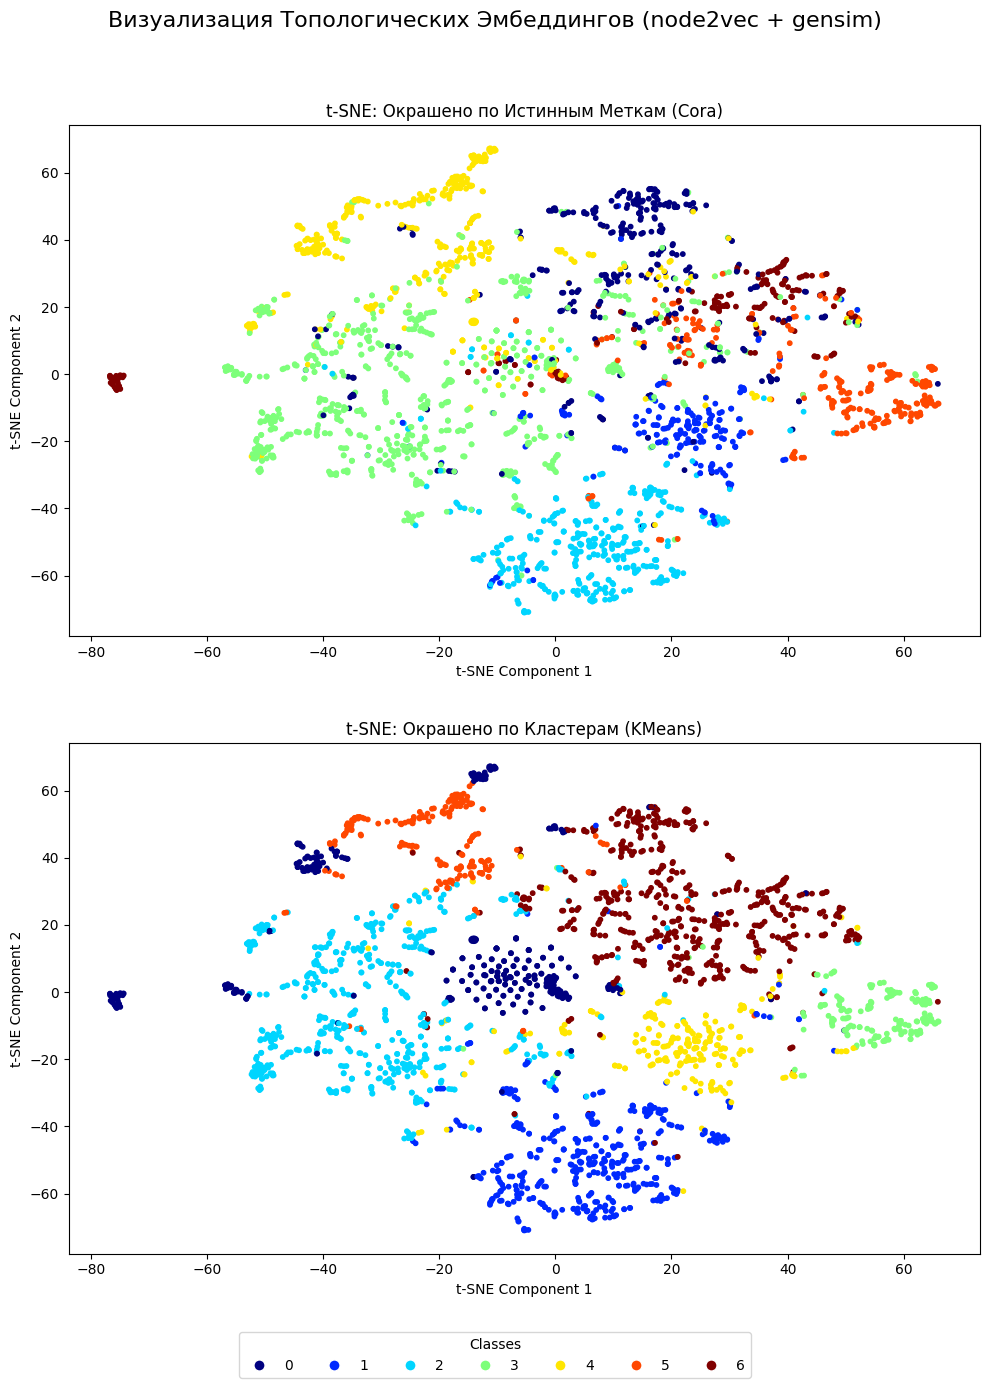

In [24]:
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.lines as mlines

labels_original = dataset[0].y.numpy()

plt.figure(figsize=(10, 14))

# График 1: Истинные метки
ax1 = plt.subplot(2, 1, 1)
labels_np = np.array(labels_original).astype(int)
scatter1 = ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_np, cmap='jet', s=10)
ax1.set_title('t-SNE: Окрашено по Истинным Меткам (Cora)')
ax1.set_xlabel('t-SNE Component 1')
ax1.set_ylabel('t-SNE Component 2')

# График 2: Метки кластеризации
ax2 = plt.subplot(2, 1, 2)
scatter2 = ax2.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, cmap='jet', s=10)
ax2.set_title('t-SNE: Окрашено по Кластерам (KMeans)')
ax2.set_xlabel('t-SNE Component 1')
ax2.set_ylabel('t-SNE Component 2')

legend_elements = []
colors = plt.cm.jet(np.linspace(0, 1, dataset.num_classes))
for i, color in enumerate(colors):
    legend_elements.append(mlines.Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor=color, markersize=8,
                                         label=f'{i}'))

plt.figlegend(handles=legend_elements, labels=[h.get_label() for h in legend_elements],
              loc='lower center', title="Classes", ncol=dataset.num_classes)


plt.suptitle('Визуализация Топологических Эмбеддингов (node2vec + gensim)', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95], h_pad=3.0)
plt.show()

# Оценка качества кластеризации (ARI и NMI)

In [25]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("Оценка качества кластеризации:")

ari = adjusted_rand_score(labels, cluster_labels)
nmi = normalized_mutual_info_score(labels, cluster_labels)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Оценка качества кластеризации:
Adjusted Rand Index (ARI): 0.3877
Normalized Mutual Information (NMI): 0.4583
